In [2]:
import torch
import matplotlib.pyplot as plt
import pandas as pd

# Задание 1

## ч1

In [3]:
def sigmoid(z):
    return 1 / (1 + torch.exp(-z))

In [21]:
def train_single_neuron(
    features,
    labels,
    initial_weights,
    initial_bias,
    learning_rate,
    epochs
):
    X = torch.tensor(features, dtype=torch.float32)
    y = torch.tensor(labels, dtype=torch.float32)

    w = torch.tensor(initial_weights, dtype=torch.float32)
    b = torch.tensor(initial_bias, dtype=torch.float32)

    nll_values = []

    for _ in range(epochs):
        z = X @ w + b
        y_hat = sigmoid(z)

        eps = 1e-8
        nll = -torch.mean(
            y * torch.log(y_hat + eps) +
            (1 - y) * torch.log(1 - y_hat + eps)
        )
        nll_values.append(round(nll.item(), 4))

        error = y_hat - y
        grad_w = torch.mean(error.unsqueeze(1) * X, dim=0)
        grad_b = torch.mean(error)

        w -= learning_rate * grad_w
        b -= learning_rate * grad_b

    return w.tolist(), float(b), nll_values

In [5]:
#Пример из домашки
features = [[1.0, 2.0], [2.0, 1.0], [-1.0, -2.0]]
labels = [1, 0, 0]
initial_weights = [0.1, -0.2]
initial_bias = 0.0
learning_rate = 0.1
epochs = 2

w, b, losses = train_single_neuron(
    features,
    labels,
    initial_weights,
    initial_bias,
    learning_rate,
    epochs
)

print(w, b, losses)


[0.10698875039815903, -0.08469319343566895] -0.033500783145427704 [0.8006, 0.7631]


In [7]:
df_train_x = pd.read_csv('train_x_1.csv')
df_train_y = pd.read_csv('train_y_1.csv')
df_train_x.head()

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,80,81,82,83,84,85,86,87,88,89
0,133081,37.47518,-14.34414,40.54872,-9.10171,16.77175,-17.77113,-16.50156,-4.09543,2.49723,...,104.03557,-115.62803,-13.79660,31.60436,28.95927,-25.93164,67.64670,-25.76691,-81.90373,-61.48682
1,111484,48.17393,-7.02208,-30.36086,-2.41924,2.15406,-8.44502,-1.68191,-8.71434,-7.83802,...,11.58664,24.58950,-36.95682,0.73922,-0.06330,53.75838,-81.05330,8.42811,12.08694,-1.91676
2,448402,36.58141,26.03203,-4.92774,35.71620,8.53080,3.73167,-7.98443,-7.43976,-1.69797,...,23.61190,-366.07968,-62.38201,113.48188,4.72741,181.64459,-134.46216,8.50795,94.15573,-8.47276
3,254414,41.15615,-17.77029,-32.30961,-21.03778,12.80330,-13.48031,-3.14951,-7.62647,-4.48901,...,25.11398,-79.64532,-77.08169,38.88094,28.52025,24.17783,-86.62542,-1.19418,-74.73449,-17.28130
4,272580,40.54855,78.77563,-23.29877,98.60192,-30.11496,26.94220,-8.87771,-3.23280,-1.04841,...,-9.89388,-252.61021,118.93768,-155.87390,51.85666,-365.15815,59.34936,52.47311,99.00695,-10.18840


In [8]:
df_train_y.head()

,Unnamed: 0,year
0,133081,2001
1,111484,2006
2,448402,1989
3,254414,1997
4,272580,2001


In [9]:
df = df_train_x.merge(
    df_train_y,
    on='Unnamed: 0',
    how='inner'
)

In [10]:
df.head()

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,81,82,83,84,85,86,87,88,89,year
0,133081,37.47518,-14.34414,40.54872,-9.10171,16.77175,-17.77113,-16.50156,-4.09543,2.49723,...,-115.62803,-13.79660,31.60436,28.95927,-25.93164,67.64670,-25.76691,-81.90373,-61.48682,2001
1,111484,48.17393,-7.02208,-30.36086,-2.41924,2.15406,-8.44502,-1.68191,-8.71434,-7.83802,...,24.58950,-36.95682,0.73922,-0.06330,53.75838,-81.05330,8.42811,12.08694,-1.91676,2006
2,448402,36.58141,26.03203,-4.92774,35.71620,8.53080,3.73167,-7.98443,-7.43976,-1.69797,...,-366.07968,-62.38201,113.48188,4.72741,181.64459,-134.46216,8.50795,94.15573,-8.47276,1989
3,254414,41.15615,-17.77029,-32.30961,-21.03778,12.80330,-13.48031,-3.14951,-7.62647,-4.48901,...,-79.64532,-77.08169,38.88094,28.52025,24.17783,-86.62542,-1.19418,-74.73449,-17.28130,1997
4,272580,40.54855,78.77563,-23.29877,98.60192,-30.11496,26.94220,-8.87771,-3.23280,-1.04841,...,-252.61021,118.93768,-155.87390,51.85666,-365.15815,59.34936,52.47311,99.00695,-10.18840,2001


In [11]:
df_binary = df[df['year'].isin([2001, 2006])].copy()
df_binary['label'] = (df_binary['year'] == 2006).astype(int)

X = df_binary.drop(columns=['Unnamed: 0', 'year', 'label']).values.tolist()
y = df_binary['label'].tolist()

In [12]:
initial_weights = [0.0] * 90
initial_bias = 0.0
learning_rate = 0.01
epochs = 50

weights, bias, nll = train_single_neuron(
    X,
    y,
    initial_weights,
    initial_bias,
    learning_rate,
    epochs
)

In [13]:
print(weights, bias, nll)


[0.272079199552536, -0.27386611700057983, 0.04128030687570572, -0.06196945160627365, 0.24918942153453827, -0.31347736716270447, 0.19715240597724915, -0.009109023958444595, -0.009671395644545555, -0.034556981176137924, -0.001265461090952158, 0.01540958322584629, 0.17634126543998718, 11.95486831665039, 6.489432334899902, 7.3844757080078125, 5.222945690155029, 3.71234130859375, 1.1837859153747559, 4.276686191558838, 0.9825916290283203, 2.2612736225128174, 1.7343590259552002, 0.12140893936157227, 1.0696443319320679, -2.0659310817718506, -0.09164232015609741, -1.0623934268951416, 1.8527743816375732, 1.2539628744125366, -1.3032124042510986, -0.11952830851078033, -0.6795967817306519, 0.015694230794906616, 0.16497954726219177, -0.563776433467865, -3.25068998336792, 1.0576212406158447, -0.920617938041687, -2.804985761642456, -1.8314712047576904, -1.2019221782684326, -0.5334601402282715, 0.28727808594703674, -0.26005953550338745, -0.3557322919368744, 5.776956081390381, 0.79878830909729, -1.46509

Интерпретация 

Большие значения весов указывают на различный масштаб признаков во входных данных. При отсутствии нормализации нейрон компенсирует масштаб признаков увеличением соответствующих весов.

Малое значение смещения указывает на то, что модель не имеет выраженного априорного предпочтения одного из классов.

Наблюдаемая немонотонность функции потерь и скачки значений NLL связаны с насыщением сигмоидной функции при больших значениях линейной комбинации признаков, что является следствием отсутствия нормализации данных

## ч2

In [20]:
def train_single_neuron_sgd(
    features,
    labels,
    initial_weights,
    initial_bias,
    learning_rate,
    epochs
):
    X = torch.tensor(features, dtype=torch.float32)
    y = torch.tensor(labels, dtype=torch.float32)

    w = torch.tensor(initial_weights, dtype=torch.float32)
    b = torch.tensor(initial_bias, dtype=torch.float32)

    nll_values = []

    for _ in range(epochs):
        total_loss = 0.0

        for xi, yi in zip(X, y):
            z = torch.dot(w, xi) + b
            y_hat = sigmoid(z)

            eps = 1e-8
            loss = - (yi * torch.log(y_hat + eps) +
                      (1 - yi) * torch.log(1 - y_hat + eps))
            total_loss += loss.item()

            error = y_hat - yi
            w -= learning_rate * error * xi
            b -= learning_rate * error

        nll_values.append(round(total_loss / len(X), 4))

    return w.tolist(), float(b), nll_values


In [15]:
def train_single_neuron_minibatch(
    features,
    labels,
    initial_weights,
    initial_bias,
    learning_rate,
    epochs,
    batch_size
):
    X = torch.tensor(features, dtype=torch.float32)
    y = torch.tensor(labels, dtype=torch.float32)

    w = torch.tensor(initial_weights, dtype=torch.float32)
    b = torch.tensor(initial_bias, dtype=torch.float32)

    nll_values = []
    eps = 1e-8
    n = X.shape[0]

    for _ in range(epochs):
        # перемешиваем данные
        perm = torch.randperm(n)
        X_shuffled = X[perm]
        y_shuffled = y[perm]

        epoch_loss = 0.0
        num_batches = 0

        for i in range(0, n, batch_size):
            X_batch = X_shuffled[i:i + batch_size]
            y_batch = y_shuffled[i:i + batch_size]

            z = X_batch @ w + b
            y_hat = sigmoid(z)

            nll = -torch.mean(
                y_batch * torch.log(y_hat + eps) +
                (1 - y_batch) * torch.log(1 - y_hat + eps)
            )

            epoch_loss += nll.item()
            num_batches += 1

            error = y_hat - y_batch
            grad_w = torch.mean(error.unsqueeze(1) * X_batch, dim=0)
            grad_b = torch.mean(error)

            w -= learning_rate * grad_w
            b -= learning_rate * grad_b

        nll_values.append(round(epoch_loss / num_batches, 4))

    return w.tolist(), float(b), nll_values


In [29]:
torch.manual_seed(42)
N = 1000
X = torch.randn(N, 2)
true_w = torch.tensor([2.0, -3.0])
true_b = 0.5
y = ((X @ true_w + true_b) > 0).float()
initial_weights = [0.0] * X.shape[1]  
initial_bias = 0.0

In [35]:
epochs = 50
learning_rate = 0.05


In [44]:
w_bg, b_bg, loss_bg = train_single_neuron(
    X.tolist(), y.tolist(),
    initial_weights, initial_bias,
    learning_rate, epochs
)

w_sgd, b_sgd, loss_sgd = train_single_neuron_sgd(
    X.tolist(), y.tolist(),
    initial_weights, initial_bias,
    learning_rate, epochs
)

w_mb, b_mb, loss_mb = train_single_neuron_minibatch(
    X.tolist(), y.tolist(),
    initial_weights, initial_bias,
    learning_rate, epochs,
    batch_size=16
)

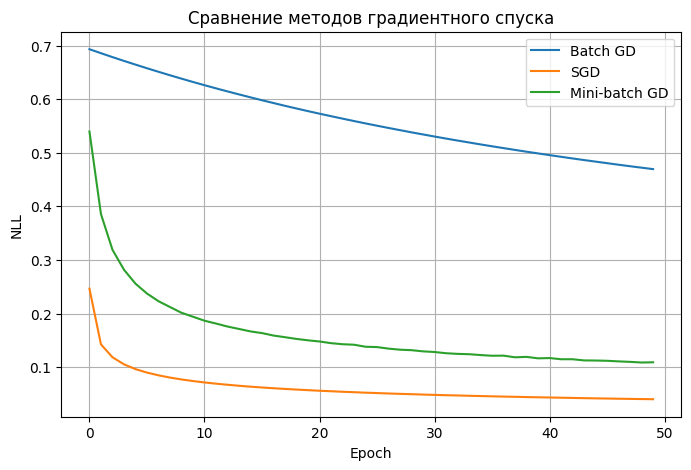

In [45]:
plt.figure(figsize=(8, 5))
plt.plot(loss_bg, label="Batch GD")
plt.plot(loss_sgd, label="SGD")
plt.plot(loss_mb, label="Mini-batch GD")
plt.xlabel("Epoch")
plt.ylabel("NLL")
plt.title("Сравнение методов градиентного спуска")
plt.legend()
plt.grid(True)
plt.show()

Для логистического нейрона с функцией потерь NLL поверхность ошибки является выпуклой. Однако при плохо обусловленных данных (разный масштаб признаков) Batch Gradient Descent движется зигзагообразно вдоль вытянутых долин, что замедляет сходимость. SGD за счёт стохастичности эффективнее проходит такие области.

В моём эксперименте mini-batch показывал худшую сходимость из-за малого объёма данных и одинакового learning rate с SGD. При небольшом числе батчей градиент получается менее устойчивым по эпохам, а более редкие обновления параметров приводят к пере- или недо-шагам, что ухудшает сходимость.

# Задание 2

In [ ]:
class Node:
    def __init__(self, data, _children=(), _op=''):
        self.data = data                  
        self.grad = 0                     
        self._backward = lambda: None     
        self._prev = set(_children)       
        self._op = _op                    

    def __repr__(self):
        return f"Node(data={self.data}, grad={self.grad})"

    def __add__(self, other):
        other = other if isinstance(other, Node) else Node(other)
        out = Node(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward

        return out


    def __mul__(self, other):
        other = other if isinstance(other, Node) else Node(other)
        out = Node(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out


    def relu(self):
        out = Node(max(0, self.data), (self,), 'ReLU')

        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward

        return out

   
    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)

        self.grad = 1.0 

        for node in reversed(topo):
            node._backward() 


In [29]:
a = Node(2)
b = Node(-3)
c = Node(10)
d = a + b * c
e = d.relu()
e.backward()

print(a, b, c, d, e)

Node(data=2, grad=0.0) Node(data=-3, grad=0.0) Node(data=10, grad=0.0) Node(data=-28, grad=0.0) Node(data=0, grad=1.0)


# Задание 3

In [ ]:
class NadamOptimizer:
    def __init__(self, params, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8):
        self.params = params  
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.m = [torch.zeros_like(p) for p in params]
        self.v = [torch.zeros_like(p) for p in params]
        self.t = 0

    def step(self, grads):
        self.t += 1
        updated_params = []
        for i, (p, g) in enumerate(zip(self.params, grads)):
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * g
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * g * g

            m_hat = self.m[i] / (1 - self.beta1 ** self.t)
            v_hat = self.v[i] / (1 - self.beta2 ** self.t)

            update = self.lr * (self.beta1 * m_hat + (1 - self.beta1) * g / (1 - self.beta1 ** self.t)) / (torch.sqrt(v_hat) + self.eps)
            p -= update
            updated_params.append(p)
        self.params = updated_params
        return updated_params


In [ ]:
def train_single_neuron_nadam(features, labels, initial_weights, initial_bias, learning_rate, epochs):
    X = torch.tensor(features, dtype=torch.float32)
    y = torch.tensor(labels, dtype=torch.float32)
    
    w = torch.tensor(initial_weights, dtype=torch.float32)
    b = torch.tensor(initial_bias, dtype=torch.float32)
    
    optimizer = NadamOptimizer([w, b], lr=learning_rate)
    
    nll_values = []
    for _ in range(epochs):
        z = X @ w + b
        y_hat = 1 / (1 + torch.exp(-z))  # сигмоида
        
        eps = 1e-8
        nll = -torch.mean(y * torch.log(y_hat + eps) + (1 - y) * torch.log(1 - y_hat + eps))
        nll_values.append(round(nll.item(), 4))
        
        error = y_hat - y
        grad_w = torch.mean(error.unsqueeze(1) * X, dim=0)
        grad_b = torch.mean(error)
        
        w, b = optimizer.step([grad_w, grad_b])
    
    return w.tolist(), float(b), nll_values


In [ ]:
# Тест - NLL уменьшается (посмотрим глазами) 
# проверка 1го задания
def test_nadam_optimizer():

    features = [[1.0, 2.0], [2.0, 1.0], [-1.0, -2.0], [-2.0, -1.0]]
    labels = [1, 1, 0, 0]

    initial_weights = [0.0, 0.0]
    initial_bias = 0.0


    w, b, losses = train_single_neuron_nadam(features, labels, initial_weights, initial_bias, 0.1, 50)

    print("Updated weights:", w)
    print("Updated bias:", b)
    print("Losses:", losses)
    print("Initial loss:", losses[0])
    print("Final loss:", losses[-1])


In [41]:
test_nadam_optimizer()

Updated weights: [1.8685221672058105, 1.8685221672058105]
Updated bias: 0.0005654572159983218
Losses: [0.6931, 0.4482, 0.3228, 0.2409, 0.1839, 0.1426, 0.1121, 0.0894, 0.0723, 0.0592, 0.0491, 0.0412, 0.0349, 0.0299, 0.0259, 0.0227, 0.02, 0.0177, 0.0159, 0.0143, 0.013, 0.0119, 0.0109, 0.0101, 0.0094, 0.0088, 0.0082, 0.0077, 0.0073, 0.0069, 0.0066, 0.0063, 0.006, 0.0058, 0.0056, 0.0054, 0.0052, 0.005, 0.0048, 0.0047, 0.0046, 0.0045, 0.0043, 0.0042, 0.0041, 0.004, 0.004, 0.0039, 0.0038, 0.0037]
Initial loss: 0.6931
Final loss: 0.0037


#### Идея Nadam

Оптимизатор **Nadam** объединяет идеи алгоритма **Adam** и ускоренного градиентного спуска Nesterow

#### Адаптивные моменты (как в Adam)

Для каждого параметра θ на шаге t поддерживаются экспоненциальные скользящие средние:

Первый момент (оценка среднего градиента):
m_t = beta1 * m_{t-1} + (1 - beta1) * g_t

Второй момент (оценка дисперсии градиента):
v_t = beta2 * v_{t-1} + (1 - beta2) * g_t^2

где g_t — градиент функции потерь по параметру θ.

Для устранения смещения на начальных шагах используется bias-correction:
m_hat_t = m_t / (1 - beta1^t)  
v_hat_t = v_t / (1 - beta2^t)


#### Nesterov momentum

В отличие от стандартного Adam, в Nadam используется **Nesterov momentum**, который учитывает ожидаемое направление движения параметров.

Модифицированный первый момент вычисляется как:
m_tilde_t = beta1 * m_hat_t + (1 - beta1) / (1 - beta1^t) * g_t

#### Обновление параметров

Итоговое правило обновления параметров:
theta_{t+1} = theta_t - alpha * m_tilde_t / (sqrt(v_hat_t) + epsilon)

где:
- alpha — скорость обучения  
- beta1, beta2 — коэффициенты экспоненциального сглаживания  


